# Pressure Field Comparison

Test runs of `CaSR` forcing field show systemic surface velocity difference in the first 24 hours, possible caused by air pressure rebalancing. This notebook explores the atmospheric pressure among different forcing fields.

## Field Visualization 

In [ ]:
# paths

path_CaSR='/ocean/jqiu/forcings/CaSR/CaSR_y2023m03d01.nc'
path_HRDPS='/results/forcing/atmospheric/continental2.5/nemo_forcing/hrdps_y2023m03d01.nc'

variable_name='atmpres'

In [5]:
# read data

import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


ds_CaSR=xr.open_dataset(path_CaSR)
ds_HRDPS=xr.open_dataset(path_HRDPS)

pressure_CaSR=ds_CaSR['atmpres'].isel(time_counter=0)
pressure_HRDPS=ds_HRDPS['atmpres'].isel(time_counter=0)

lon_CaSR = ds_CaSR["nav_lon"]
lat_CaSR = ds_CaSR["nav_lat"]

lon_HRDPS = ds_HRDPS["nav_lon"]
lat_HRDPS = ds_HRDPS["nav_lat"]

# Pa2hPa

pressure_CaSR = pressure_CaSR / 100.0
pressure_HRDPS = pressure_HRDPS / 100.0


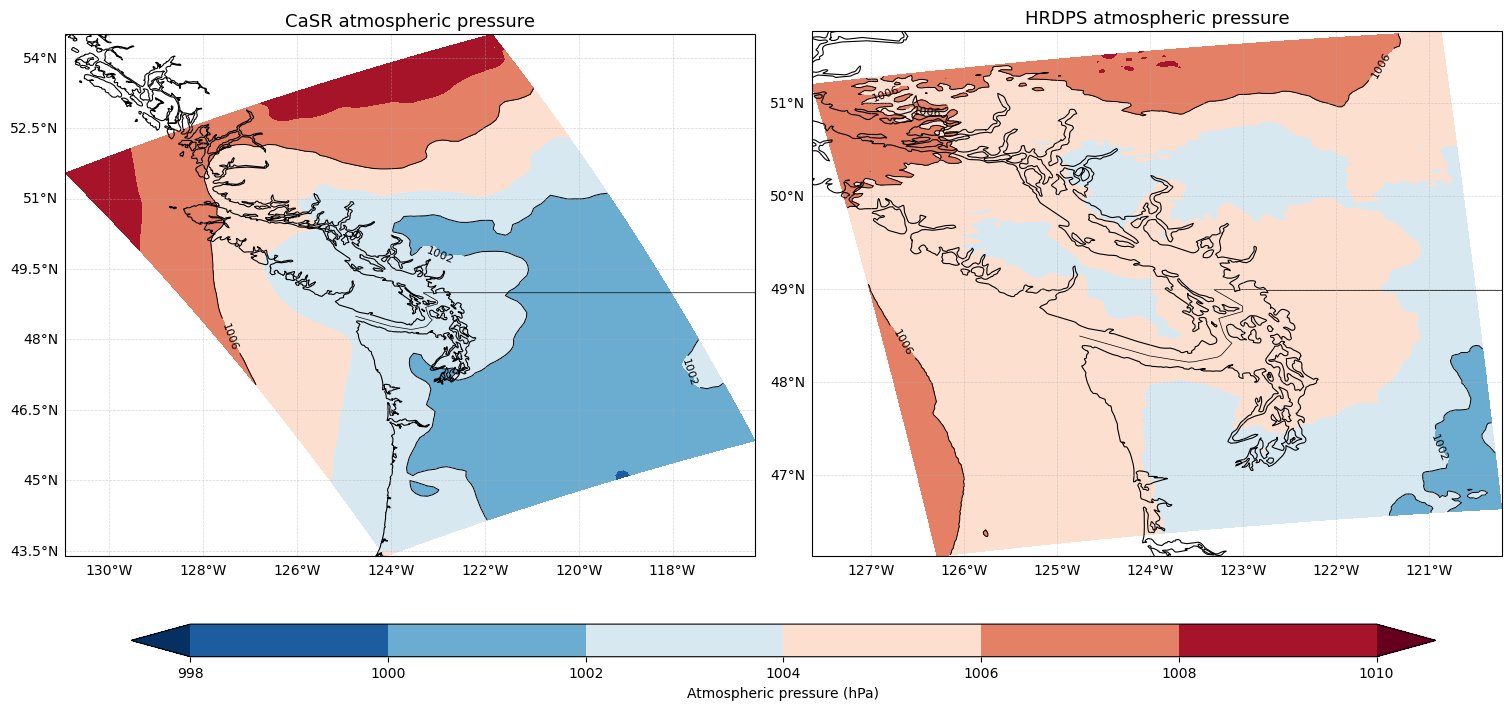

In [7]:
# visualize
# -------------------------
# 设置统一的等压线范围
# -------------------------
pmin = min(
    float(pressure_CaSR.min()),
    float(pressure_HRDPS.min()),
)

pmax = max(
    float(pressure_CaSR.max()),
    float(pressure_HRDPS.max()),
)

# 以 2 hPa 为间隔，覆盖两个数据集的范围
import numpy as np

level_min = 2 * np.floor(pmin / 2)
level_max = 2 * np.ceil(pmax / 2)

filled_levels = np.arange(level_min, level_max + 2, 2)
contour_levels = np.arange(level_min, level_max + 4, 4)


# -------------------------
# 创建对比图
# -------------------------
projection = ccrs.PlateCarree()

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(15, 7),
    subplot_kw={"projection": projection},
    constrained_layout=True,
)


datasets = [
    {
        "ax": axes[0],
        "pressure": pressure_CaSR,
        "lon": lon_CaSR,
        "lat": lat_CaSR,
        "title": "CaSR atmospheric pressure",
    },
    {
        "ax": axes[1],
        "pressure": pressure_HRDPS,
        "lon": lon_HRDPS,
        "lat": lat_HRDPS,
        "title": "HRDPS atmospheric pressure",
    },
]


for item in datasets:
    ax = item["ax"]
    pressure = item["pressure"]
    lon = item["lon"]
    lat = item["lat"]

    # 填色气压场
    filled = ax.contourf(
        lon,
        lat,
        pressure,
        levels=filled_levels,
        cmap="RdBu_r",
        extend="both",
        transform=ccrs.PlateCarree(),
    )

    # 黑色等压线
    contours = ax.contour(
        lon,
        lat,
        pressure,
        levels=contour_levels,
        colors="black",
        linewidths=0.7,
        transform=ccrs.PlateCarree(),
    )

    ax.clabel(
        contours,
        inline=True,
        fontsize=8,
        fmt="%.0f",
    )

    ax.coastlines(resolution="10m", linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    ax.set_title(item["title"], fontsize=13)

    gridlines = ax.gridlines(
        draw_labels=True,
        linewidth=0.5,
        linestyle="--",
        alpha=0.5,
    )

    gridlines.top_labels = False
    gridlines.right_labels = False


# -------------------------
# 两幅图共用一个色标
# -------------------------
cbar = fig.colorbar(
    filled,
    ax=axes,
    orientation="horizontal",
    fraction=0.06,
    pad=0.08,
    aspect=40,
)

cbar.set_label("Atmospheric pressure (hPa)")



plt.show()